In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent, EDM4hepEventBatch

import logging

# Configure logging to show INFO level messages
logging.basicConfig(
    level=logging.INFO,
    format='%(name)s -| %(levelname)s - %(message)s'
)

# Optional: Set specific logger level for pyedm4hep
logger = logging.getLogger('pyedm4hep.event_batch')
logger.setLevel(logging.INFO)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading

In [5]:
# Define conservative detector parameters
detector_params = {
    'tracking_radius': 1080,    # in mm
    'tracking_z_max': 3030,     # in mm
    'energy_threshold': 0.     # in GeV
}

edm_input_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/0/edm4hep.root"
batch = EDM4hepEventBatch(edm_input_file, events=(0, 2), full_load=False, detector_params=detector_params)

In [6]:
tracker_hits = batch.get_tracker_hits_df()
calo_hits = batch.get_calo_hits_df()
calo_contributions = batch.get_calo_contributions_df()
particles = batch.get_particles_df()
print(f"""
Unique events IDs in particles: {particles.event_id.unique()}
Length of particles: {len(particles)}
Length of tracker_hits: {len(tracker_hits)}
Length of calo_hits: {len(calo_hits)}
Length of calo_contributions: {len(calo_contributions)}
Events with non-empty calo_hits: {calo_hits.event_id.unique()}
""")

pyedm4hep.event_batch - INFO -   ↳ PixelBarrelReadout: 0.0650s (83977 rows)
pyedm4hep.event_batch - INFO -       • read: 0.0332s, to_df: 0.0086s, links: 0.0115s, derived: 0.0086s
pyedm4hep.event_batch - INFO -   ↳ PixelEndcapReadout: 0.0670s (78027 rows)
pyedm4hep.event_batch - INFO -       • read: 0.0320s, to_df: 0.0086s, links: 0.0140s, derived: 0.0091s
pyedm4hep.event_batch - INFO -   ↳ ShortStripBarrelReadout: 0.0729s (86825 rows)
pyedm4hep.event_batch - INFO -       • read: 0.0367s, to_df: 0.0096s, links: 0.0125s, derived: 0.0104s
pyedm4hep.event_batch - INFO -   ↳ ShortStripEndcapReadout: 0.0727s (78690 rows)
pyedm4hep.event_batch - INFO -       • read: 0.0352s, to_df: 0.0099s, links: 0.0127s, derived: 0.0099s
pyedm4hep.event_batch - INFO -   ↳ LongStripBarrelReadout: 0.0493s (36537 rows)
pyedm4hep.event_batch - INFO -       • read: 0.0263s, to_df: 0.0051s, links: 0.0100s, derived: 0.0055s
pyedm4hep.event_batch - INFO -   ↳ LongStripEndcapReadout: 0.0568s (45414 rows)
pyedm4hep.e

Any NAN values:  event_id       False
subentry       False
energy         False
time           False
particle_id    False
detector       False
hit_index      False
cellID         False
dtype: bool


pyedm4hep.utils - INFO -       ✓ condensation complete: 5.4599s (2956730 condensed rows)
pyedm4hep.event_batch - INFO -   ↳ condensation: 5.5180s (2956730 condensed rows)
pyedm4hep.event_batch - INFO - ⏱️  _load_calo_contributions: 10.4750s (2956730 contributions)
pyedm4hep.event_batch - INFO -   ↳ particles loaded: 0.2380s (356533 rows)
pyedm4hep.event_batch - INFO -   ↳ links loaded: 0.0443s (parents=629052, daughters=0)
pyedm4hep.event_batch - INFO - ⏱️  _load_particles_and_links: 0.5316s total
pyedm4hep.utils - INFO -   ⏱️  groupby tracker_hits (409470 rows)...
pyedm4hep.utils - INFO -       ✓ tracker: 0.0459s (groupby: 0.0219s, merge: 0.0234s)
pyedm4hep.utils - INFO -   ⏱️  groupby calo_contributions (2956730 rows)...
pyedm4hep.utils - INFO -       ✓ calo: 0.1027s (groupby: 0.0810s, merge: 0.0214s)
pyedm4hep.event_batch - INFO -   ⏱️  augment_particles breakdown:
pyedm4hep.event_batch - INFO -       • identifiers: 0.0118s
pyedm4hep.event_batch - INFO -       • kinematics: 0.0041s



Unique events IDs in particles: [0 1]
Length of particles: 356533
Length of tracker_hits: 409470
Length of calo_hits: 2100215
Length of calo_contributions: 2956730
Events with non-empty calo_hits: [0 1]



In [ ]:
calo_digi_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/0/edm4hep_digitized.root"
calo_batch = EDM4hepEventBatch(calo_digi_file, events=(0, 10), full_load=False, detector_params=detector_params)

In [ ]:
calo_tracker_hits = calo_batch.get_tracker_hits_df()
calo_truth_hits = calo_batch.get_calo_hits_df()
calo_digi_hits = calo_batch.get_digi_calo_hits_df()
calo_digi_contributions = calo_batch.get_calo_contributions_df()
calo_particles = calo_batch.get_particles_df()
print(f"""
Unique events IDs in particles: {calo_particles.event_id.unique()}
Length of particles: {len(calo_particles)}
Length of calo_tracker_hits: {len(calo_tracker_hits)}
Length of calo_truth_hits: {len(calo_truth_hits)}
Length of calo_digi_contributions: {len(calo_digi_contributions)}
Length of calo_digi_hits: {len(calo_digi_hits)}
Events with non-empty calo_digi_hits: {calo_digi_hits.event_id.unique()}
""")

pyedm4hep.event_batch - INFO -   ↳ PixelBarrelReadout: 0.2055s (516793 rows)
pyedm4hep.event_batch - INFO -       • read: 0.0599s, to_df: 0.0271s, links: 0.0456s, derived: 0.0558s
pyedm4hep.event_batch - INFO -   ↳ PixelEndcapReadout: 0.1946s (486728 rows)
pyedm4hep.event_batch - INFO -       • read: 0.0693s, to_df: 0.0244s, links: 0.0390s, derived: 0.0463s
pyedm4hep.event_batch - INFO -   ↳ ShortStripBarrelReadout: 0.1947s (534061 rows)
pyedm4hep.event_batch - INFO -       • read: 0.0527s, to_df: 0.0275s, links: 0.0423s, derived: 0.0549s
pyedm4hep.event_batch - INFO -   ↳ ShortStripEndcapReadout: 0.2028s (489132 rows)
pyedm4hep.event_batch - INFO -       • read: 0.0637s, to_df: 0.0239s, links: 0.0477s, derived: 0.0528s
pyedm4hep.event_batch - INFO -   ↳ LongStripBarrelReadout: 0.1363s (239557 rows)
pyedm4hep.event_batch - INFO -       • read: 0.0605s, to_df: 0.0129s, links: 0.0306s, derived: 0.0251s
pyedm4hep.event_batch - INFO -   ↳ LongStripEndcapReadout: 0.1666s (278082 rows)
pyedm


Unique events IDs in particles: [0 1 2 3 4 5 6 7 8 9]
Length of particles: 2255835
Length of calo_tracker_hits: 2544353
Length of calo_truth_hits: 12959845
Length of calo_digi_contributions: 63055700
Length of calo_digi_hits: 4732623
Events with non-empty calo_digi_hits: [0 1 2 3 4 5 6 7 8 9]



## Roadmap

1. How many tracker hits vs sim calo hits?
2. How many sim calo hits vs digi calo hits?
3. What is the maximum energy I can cut that retains the resolution of electrons and pions? Use single particles
    1. Apply cut E_cut at sim level
    2. Calculate sum and merge
    3. Calculate mean resolution and variance
    4. Don't want to drop more than ~10% relative to pre-cut
4. Given max energy cut...
5. How many contributions per cell?
6. What is the energy of the first, second, third, fourth contribution to each cell (assuming contributions are condensed)? Absolute and relative to cell energy
7. For "important particles" (>1GeV), how much of their energy is left as >= second, third, fourth contribution to a cell

In [12]:
num_tracker_hits = calo_tracker_hits.groupby("event_id").count()["subentry"].values
num_sim_calo_hits = calo_truth_hits.groupby("event_id").count()["subentry"].values
num_digi_calo_hits = calo_digi_hits.groupby("event_id").count()["subentry"].values

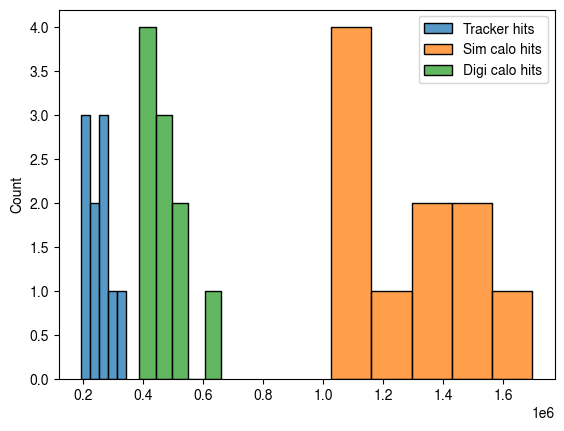

In [15]:
sns.histplot(num_tracker_hits, label="Tracker hits")
sns.histplot(num_sim_calo_hits, label="Sim calo hits")
sns.histplot(num_digi_calo_hits, label="Digi calo hits")
plt.legend()